# PART 1

### (1) Policy gradients 

1. def MDP for underlying env: <br>
Set states S: {empty bowl, full bowl, sugared_bowl, salted_bowl, sugar_sampling, salt_sampling, baked_sugar_cookies, baked_salty_cookies} <br>
Set actions A: {wait, prep_dough} in s1 <br> 
            {wait, add_sugar, add_salt} in s2 <br>
            {...} <br>
Set transitions == result(action) as transitions here deterministic <br>
Set Rewards = {+10, if baked sugary cookies, -10 if baked salty cookies} <br>
discount factor \gamma // in this case something like 0.99 


2. On paper: 

3. Can define an optimal deterministic policy as all states are observable and transitions deterministic: <br>
pi(a|s) = <br>
prep_dough | empty bowl // add_sugar | full_bowl // cook | sugared_bowl <br>
 // cook | sugar_sampling // restart | salted_bowl //return_to_bowl | salt_sampling

4. an optimal stochastic policy here doesnt make sense as any probability for action a not equal to 1 for state n as specified above yields worse return for a trajectory than following the policy stated above. 

5. New MDP: (whole point here is to introduce stochastic transitions) <br>
Set states S: {empty_bowl, enriched_bowl,(...)} , if enriched, latent var \sigma keeps track of if sugar/salt <br>
Set actions A: {wait, add_ingredient, taste, cook, restart}.. actions available obvi state dependenpt but didnt bother specify again <br>
Set transitions no longer deterministic, transitions depend on latent var \sigma if state = enriched_bowl. 
Rewards same as last time, 
discount factor \gamma if neccesary. 

6. On paper:(with 2...)

7. Would argue one can determine an optimal deterministic strategy here, because selecting the action taste in state enriched bowl reveals the value of our latent variable \sigma. Therefore, an optimal deterministic policy here simply involves another action. <br>
pi(a|s) = add_ingredient | empty_bowl // taste | enriched_bowl // <br>
further, the clue is that we now transfer to either sugar_sampling or salt_sampling, which i assume reveals if \sigma is sugar or salt. We can model this as \sigma \elem {0, 1}, with 0 being sugar, 1 being salt, and P(\sigma = 0) = \epsilon, P(\sigma = 1) = 1-\epsilon. This epsilon only exits as a probability before the taste action is selected, and will be either 0 or 1 after. This means that for our deterministic optimal strategy, our following specified pi(a|s) would be restart | salty, cook | sugary ...
If instead \sigma stays latent the whole trajectory, even if taste is selected, then one cannot find a deterministic optimal strategy. 

8. As said above, depends entirely on if one assumes \sigma. stays latent the whole time. If it does, one would select a stochastic policy where each action is dependent on the epsilon introduced above. 

9. The diference is the latent variable \sigma. The introduction of uncertain transitions through \simga means one wishes to cook as little as possible if P(\sigma = 1) > P(\sigma = 0), meaning if one believes one transitions to salt more often than not one would avoid cooking cookies and vice verca. 

10. If my assumption is wrong, it would naturally be for the agent to be sure to observe which state one ends up in, even after an uncertain transition, as the agent could then abuse this feecback loop for a deterministic strategy in the form of: if in sugary_sampling => cook, else: restart. 

### (2) Continous Actions

1. def neural network s.t. output = dist(actions): would need a softmax at the end to achieve a boltzmann dist. <br>
(output under + formula gen(chatGPT))
For a finite action space A = {a1, ..., an}, we define a neural network that takes the state s as input and outputs n real-valued scores, one for each action. These outputs are then passed through a softmax function, so that the final layer gives a valid probability distribution over actions: <br>
π(ai|s) = exp(zi(s)) / Σj exp(zj(s)).

2. asssume continous action space: then, i would propose using a gaussian distribution. Hence: pi(a|s) ~N(u, \sigma^2) <br>
by using 1/sqrt(2*pi *\sigma^2) * e^-((x-u)^2)/2


3. to work with a continous distribution, i would need a parameter for the mean and variance of my assumed distribution. 

4. A clean way to define a nn s.t. the ouput is a distribution in R is to let our policy approx function output the parameters of a gaussian dist, with some transformation of \sigma^2 to make sure it is positive for all n \elem R.  

5. The assumptions that underly my probability dist? well the assumptions of the gaussian? or atleast that my attempted approximation of the gaussian is symmetric ish around the mean, has positive variance, that our chosen params actually capture the relevant info, space is actually continous? A = R, with R being the set of all real numbers. 

### (3) MAB and Baselines

1. The term in the update rule of gradient bandits that play a similar role to a baseline in a policy gradient bandit is the subtraction of the estimated mean: the relevant part of the formula gives \alpha(R^(t)-R^hat^(t))(1-prob^t(a)). The meaning is to compare our return R^t to what we believe is the mean at this point, s.t. the size of the gain/loss of selecting an action a at time t is reduced(variance reduction is once again the purpose). Which is exactly what one wishes to achieve with a baseline in policy gradient algos. 

2.  The way R^hat^(t) changes the learning part is that now our update depends on wether our current reward is better/worse than the avg, and not just the absolute size ogf the reward(in this case from arm pull a). This is beneficial for the same reasons as mentioned above: smaller changes(less variance), and a referance value senters the signal. 

### (4) Actor Critic methods 

1. Not entirely sure if i correctly understand the q. critic is somewhat similar to policy eval, actor somewhat to policy improvement. noticably, they both differ because they are approximations(insted of exact), and with actor-critic both happpen simultaneously, instead of a alternating loop(eval-improvement-eval- improvement and so on). 

# PART2

In [11]:
import gymnasium as gym
import cookiedisaster

env = gym.make('cookiedisaster/GridWorld-v0')

In [12]:
"""task best described as episodic or continuing? would argue continuing, as i dont see an obvious state
/ time for episode/trajectory termination.""" 

'task best described as episodic or continuing? would argue continuing, as i dont see an obvious state\n/ time for episode/trajectory termination.'

2. linear approx of q_pi(a, s) and solving the control prob with q-learning + feature eng= 

In [13]:
#obj, retreive cookies
#cookie expiry timer = 5secs 
#1d representation 

print(env.observation_space, env.action_space)


action = env.action_space.sample()
env.reset()
observation, reward, terminated, truncated, info = env.step(action)
print(observation, reward, terminated, truncated, info)

#friction = -(velocity^2*0.005), change in pos = pos(t+\delta) = pos(t) + action(t) + friction(t)*\delta



Box([  0. -inf   0.], [10. inf 10.], (3,), float32) Discrete(3)
{'agent': {'pos': 4.2, 'vel': 1.0}, 'cookie': {'pos': 0.27103054454295206, 'time': 5}} 0 False False {'distance': 3.928969455457048, 'steps': 1}


In [14]:
import numpy as np

NUM_ACTIONS = env.action_space.n
state = env.reset()
print(state[0])
print(state[1])


{'agent': {'pos': 4, 'vel': 0.0}, 'cookie': {'pos': 0.13233816821190736, 'time': 5}}
{'distance': 3.8676618317880926, 'steps': 0}


In [15]:
#Linear function approximator for q(a, s): q_hat(s, a) = w^T phi(s, a)
N_ACTIONS = env.action_space.n

def state_features(obs):
    # Raw components from observation dict
    agent_pos = float(obs['agent']['pos'])
    agent_velocity = float(obs['agent']['vel'])
    cookie_pos = float(obs['cookie']['pos'])
    cookie_timer = float(obs['cookie']['time'])

    # Normalization based on known environment ranges
    # pos approx in [0, 10], timer approx in [0, 5]
    agent_pos_norm = (agent_pos - 5.0) / 5.0
    cookie_pos_norm = (cookie_pos - 5.0) / 5.0
    velocity_norm = np.tanh(agent_velocity / 5.0)
    timer_norm = (cookie_timer - 2.5) / 2.5

    # Relative geometry/motion features
    delta_pos = agent_pos_norm - cookie_pos_norm
    abs_delta_pos = abs(delta_pos)
    closing_speed = -np.sign(delta_pos) * velocity_norm

    # Event-style binary indicators
    fast_flag = 1.0 if abs(agent_velocity) > 4.0 else 0.0
    near_left_wall = 1.0 if agent_pos < 0.5 else 0.0
    near_right_wall = 1.0 if agent_pos > 9.5 else 0.0
    timer_expired = 1.0 if cookie_timer <= 0.0 else 0.0

    return np.array([
        1.0,  # bias
        agent_pos_norm,
        velocity_norm,
        cookie_pos_norm,
        timer_norm,
        delta_pos,
        abs_delta_pos,
        velocity_norm * velocity_norm,
        delta_pos * velocity_norm,
        closing_speed,
        fast_flag,
        near_left_wall,
        near_right_wall,
        timer_expired,
    ], dtype=np.float32)

def phi(obs, action, n_actions=N_ACTIONS):
    psi = state_features(obs)
    feature_vector = np.zeros(n_actions * psi.size, dtype=np.float32)
    start_index = action * psi.size
    feature_vector[start_index:start_index + psi.size] = psi
    return feature_vector

def q_hat(obs, action, weights):
    return float(np.dot(weights, phi(obs, action)))

def q_values(obs, weights):
    return np.array([q_hat(obs, a, weights) for a in range(N_ACTIONS)], dtype=np.float32)

def epsilon_greedy(obs, weights, epsilon=0.1):
    if np.random.rand() < epsilon:
        return int(np.random.randint(N_ACTIONS))
    return int(np.argmax(q_values(obs, weights)))

# Initialize parameters for linear q(a, s) approximator
psi_dim = state_features(state[0]).size
weights = np.zeros(N_ACTIONS * psi_dim, dtype=np.float32)

print('feature dimension per action:', psi_dim)
print('total parameter dimension:', weights.size)

# Quick sanity check
feat_vis = phi(state[0], action=0)
print('phi shape:', feat_vis.shape)
print('non-zero elements in phi(action=0):', int(np.count_nonzero(feat_vis)))
print('initial q-values:', q_values(state[0], weights))

feature dimension per action: 14
total parameter dimension: 42
phi shape: (42,)
non-zero elements in phi(action=0): 6
initial q-values: [0. 0. 0.]


In [16]:
# Semi-gradient Q-learning with linear function approximation
def run_linear_q_learning(
    initial_weights,
    n_episodes=1000,
    max_steps=200,
    alpha=0.03,
    gamma=0.99,
    eps_start=0.20,
    eps_end=0.03,
    eps_decay=120.0,
    seed_base=0,
    env_id='cookiedisaster/GridWorld-v0',
):
    current_weights = initial_weights.copy()
    train_env = gym.make(env_id)

    episode_returns = []
    epsilons = []
    mean_abs_td_error = []
    action_counts = []

    for episode_index in range(n_episodes):
        observation, _ = train_env.reset(seed=seed_base + episode_index)
        episode_return = 0.0
        epsilon = eps_end + (eps_start - eps_end) * np.exp(-episode_index / eps_decay)
        epsilons.append(float(epsilon))

        td_errors_this_episode = []
        action_count_vec = np.zeros(N_ACTIONS, dtype=np.int32)

        for _ in range(max_steps):
            action_index = epsilon_greedy(observation, current_weights, epsilon)
            action_count_vec[action_index] += 1

            next_observation, reward, terminated, truncated, _ = train_env.step(action_index)

            q_sa = q_hat(observation, action_index, current_weights)
            next_q_max = float(np.max(q_values(next_observation, current_weights)))
            td_target = reward + gamma * next_q_max
            td_error = td_target - q_sa

            current_weights += alpha * td_error * phi(observation, action_index)
            td_errors_this_episode.append(abs(float(td_error)))

            episode_return += reward
            observation = next_observation

            if terminated or truncated:
                break

        episode_returns.append(float(episode_return))
        mean_abs_td_error.append(float(np.mean(td_errors_this_episode)) if td_errors_this_episode else 0.0)
        action_counts.append(action_count_vec)

    train_env.close()

    training_stats = {
        'mean_last_20': float(np.mean(episode_returns[-20:])),
        'best_return': float(np.max(episode_returns)),
        'first_10': [round(x, 3) for x in episode_returns[:10]],
        'last_10': [round(x, 3) for x in episode_returns[-10:]],
    }

    diagnostics = {
        'epsilons': np.array(epsilons, dtype=np.float32),
        'mean_abs_td_error': np.array(mean_abs_td_error, dtype=np.float32),
        'action_counts': np.array(action_counts, dtype=np.int32),
    }

    return episode_returns, current_weights, training_stats, diagnostics

returns, weights, training_stats, diagnostics = run_linear_q_learning(initial_weights=weights)

print('Training complete.')
print('Mean return last 20 episodes:', training_stats['mean_last_20'])
print('Best return seen:', training_stats['best_return'])
print('First 10 returns:', training_stats['first_10'])
print('Last 10 returns:', training_stats['last_10'])

Training complete.
Mean return last 20 episodes: 14.292718655026693
Best return seen: 24.089391352205404
First 10 returns: [-10.892, -4.815, 2.082, 1.201, 6.127, 7.361, 6.611, 7.056, 6.819, 8.474]
Last 10 returns: [14.774, 16.417, 14.5, 9.91, 12.0, 17.349, 16.149, 13.38, 14.352, 14.347]


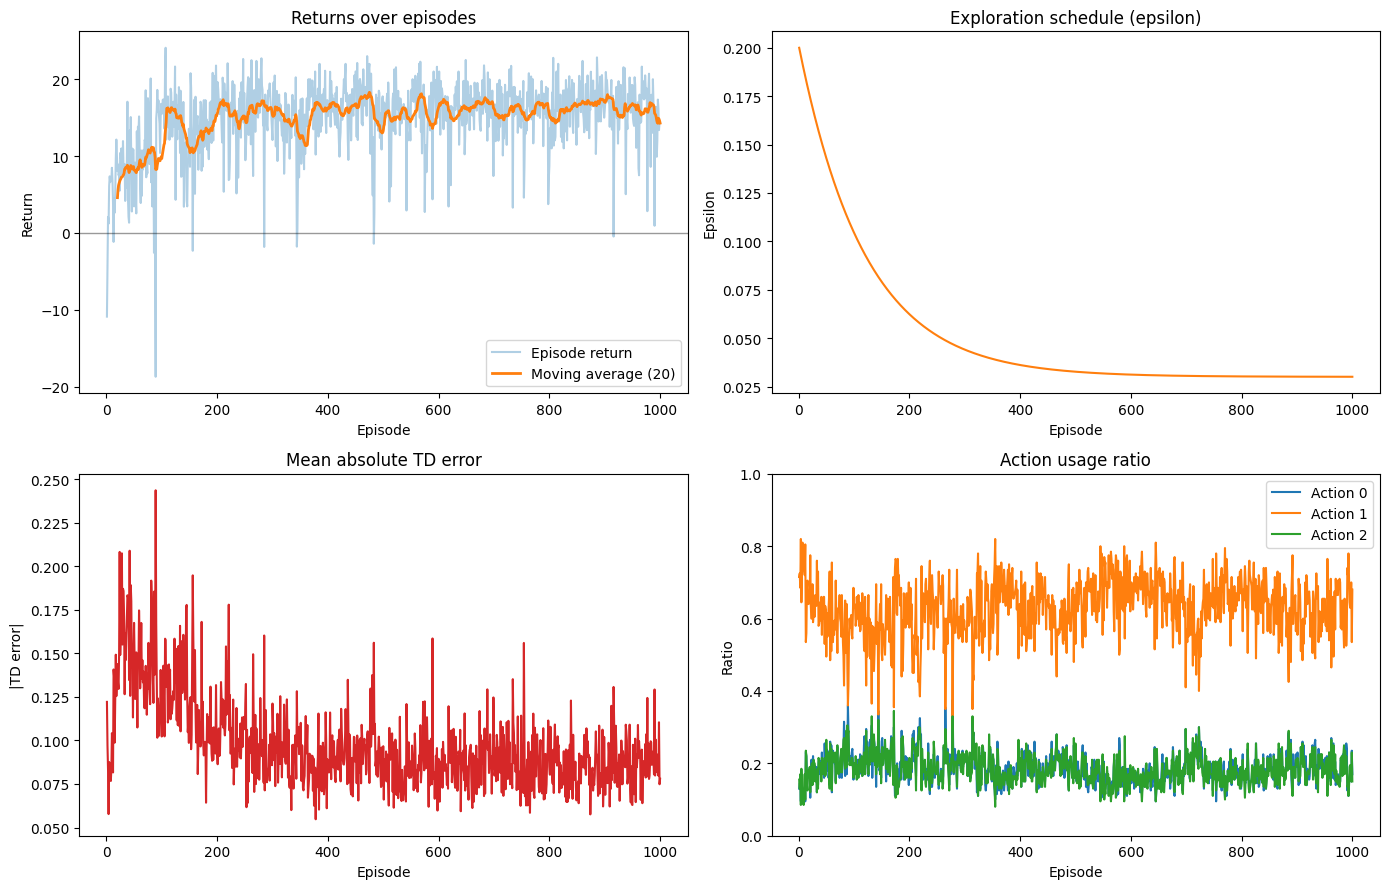

In [17]:
import matplotlib.pyplot as plt

def plot_linear_q_learning_results(returns, diagnostics, window=20):
    ret = np.asarray(returns, dtype=float)
    eps = np.asarray(diagnostics['epsilons'], dtype=float)
    td_abs = np.asarray(diagnostics['mean_abs_td_error'], dtype=float)
    action_counts = np.asarray(diagnostics['action_counts'], dtype=float)
    episodes = np.arange(1, len(ret) + 1)

    # Smoothed returns
    if len(ret) >= 2:
        window = min(window, len(ret))
        kernel = np.ones(window, dtype=float) / window
        ret_ma = np.convolve(ret, kernel, mode='valid')
        ret_ma_x = np.arange(window, len(ret) + 1)
    else:
        ret_ma = ret.copy()
        ret_ma_x = episodes

    # Action usage ratio per episode
    action_ratios = action_counts / np.maximum(action_counts.sum(axis=1, keepdims=True), 1.0)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(episodes, ret, alpha=0.35, label='Episode return')
    axes[0, 0].plot(ret_ma_x, ret_ma, linewidth=2.0, label=f'Moving average ({window})')
    axes[0, 0].axhline(0.0, color='black', linewidth=1, alpha=0.4)
    axes[0, 0].set_title('Returns over episodes')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Return')
    axes[0, 0].legend()

    axes[0, 1].plot(episodes, eps, color='tab:orange')
    axes[0, 1].set_title('Exploration schedule (epsilon)')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Epsilon')

    axes[1, 0].plot(episodes, td_abs, color='tab:red')
    axes[1, 0].set_title('Mean absolute TD error')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('|TD error|')

    for action_index in range(action_ratios.shape[1]):
        axes[1, 1].plot(episodes, action_ratios[:, action_index], label=f'Action {action_index}')
    axes[1, 1].set_ylim(0.0, 1.0)
    axes[1, 1].set_title('Action usage ratio')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Ratio')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

plot_linear_q_learning_results(returns, diagnostics, window=20)

Seems like Q-learning with manual feature eng + linear function approx works okay, next step to implement a NN for the action-value approx instead. 


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

#Simple MLP for Q(s, a) with online Q-learning updates
class QMLP(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)

def obs_to_vec(obs):
    #simply reusing engineered features. 
    return state_features(obs)

def run_simple_mlp_q_learning(
    n_episodes=1000,
    max_steps=200,
    gamma=0.99,
    learning_rate=1e-3,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    seed=0,
    env_id='cookiedisaster/GridWorld-v0',
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(env_id)
    n_actions = env.action_space.n
    input_dim = obs_to_vec(env.reset(seed=seed)[0]).shape[0]

    model = QMLP(input_dim, n_actions)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.SmoothL1Loss()

    episode_returns = []
    losses = []
    epsilon = eps_start

    for episode_idx in range(n_episodes):
        obs, _ = env.reset(seed=seed + episode_idx)
        state_vec = obs_to_vec(obs)
        episode_return = 0.0

        for _ in range(max_steps):
            if np.random.rand() < epsilon:
                action = int(np.random.randint(n_actions))
            else:
                with torch.no_grad():
                    state_tensor = torch.tensor(state_vec, dtype=torch.float32).unsqueeze(0)
                    action = int(torch.argmax(model(state_tensor), dim=1).item())

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state_vec = obs_to_vec(next_obs)

            state_tensor = torch.tensor(state_vec, dtype=torch.float32).unsqueeze(0)
            next_state_tensor = torch.tensor(next_state_vec, dtype=torch.float32).unsqueeze(0)

            q_values_current = model(state_tensor)
            q_sa = q_values_current[0, action]

            with torch.no_grad():
                next_q_max = torch.max(model(next_state_tensor), dim=1).values.item()
                target_value = reward + (0.0 if done else gamma * next_q_max)
                target_tensor = torch.tensor(target_value, dtype=torch.float32)

            loss = loss_fn(q_sa, target_tensor)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimizer.step()

            losses.append(float(loss.item()))
            episode_return += reward
            state_vec = next_state_vec

            if done:
                break

        episode_returns.append(float(episode_return))
        epsilon = max(eps_end, epsilon * eps_decay)

    env.close()

    stats = {
        'mean_last_20': float(np.mean(episode_returns[-20:])),
        'best_return': float(np.max(episode_returns)),
        'loss_count': len(losses),
    }
    return episode_returns, losses, model, stats

mlp_returns, mlp_losses, mlp_model, mlp_stats = run_simple_mlp_q_learning()
print('Simple MLP Q-learning complete.')
print('Mean return last 20 episodes:', mlp_stats['mean_last_20'])
print('Best return seen:', mlp_stats['best_return'])
print('Number of optimization steps:', mlp_stats['loss_count'])

c:\pythonlek\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\pythonlek\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:130: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'dict'>
  logger.warn(
c:\pythonlek\.venv\Lib\site-packages\gymnasium\spaces\box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
c:\pythonlek\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\pythonlek\.

Simple MLP Q-learning complete.
Mean return last 20 episodes: 17.55639147812709
Best return seen: 26.791194850417895
Number of optimization steps: 200000


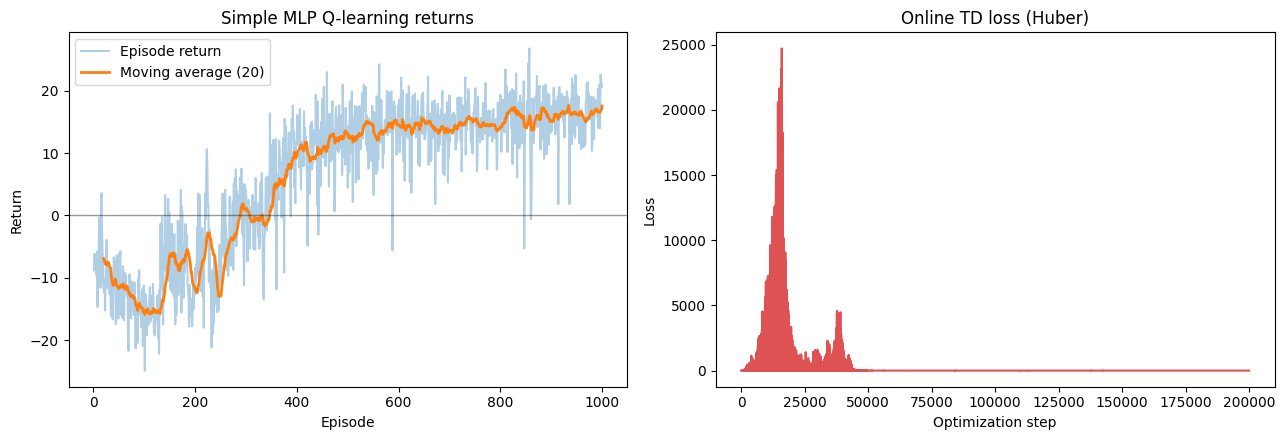

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_simple_mlp_q_learning(episode_returns, losses, window=20):
    returns_np = np.asarray(episode_returns, dtype=float)
    episodes = np.arange(1, len(returns_np) + 1)

    window = min(window, len(returns_np)) if len(returns_np) > 0 else 1
    if len(returns_np) >= 2:
        kernel = np.ones(window) / window
        returns_ma = np.convolve(returns_np, kernel, mode='valid')
        returns_ma_x = np.arange(window, len(returns_np) + 1)
    else:
        returns_ma = returns_np
        returns_ma_x = episodes

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(episodes, returns_np, alpha=0.35, label='Episode return')
    axes[0].plot(returns_ma_x, returns_ma, linewidth=2.0, label=f'Moving average ({window})')
    axes[0].axhline(0.0, color='black', linewidth=1, alpha=0.4)
    axes[0].set_title('Simple MLP Q-learning returns')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Return')
    axes[0].legend()

    losses_np = np.asarray(losses, dtype=float)
    axes[1].plot(losses_np, alpha=0.8, color='tab:red')
    axes[1].set_title('Online TD loss (Huber)')
    axes[1].set_xlabel('Optimization step')
    axes[1].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()

plot_simple_mlp_q_learning(mlp_returns, mlp_losses, window=20)

### (4)

For the first implementation of q-learning, a linear function approximation with engineered features was used. The features were agent_position, agent_velocity, cookie_position and cookie_timer, then those features with normalized values to make our algorithm less sensitive to the larger numbers, and also some relative futures(distance(agent, cookie)), and some event features such as near_left_wall and same for right etc. The product of these features times our initialized weights was used to approximate our action value function, which takes the pair (action, state) as argument and gives our estimated "value". For the neural network we used a 3-layer MLP with ReLU activation and our engineered features as input. 

The results were fairly similar, however one notices that the version with a Neural Network as our function approximator took a lot longer to reach good returns/episode. Also worth noting that this is the results of a simpler NN implementation without a replay buffer and/or a target network. 

### Actor-Critic implementation

Actor-Critic training complete.
Mean return last 20 episodes: 24.632481733363612
Best return seen: 34.0
Last 10 returns: [23.807, 25.93, 26.742, 20.729, 23.384, 22.589, 25.0, 27.242, 27.222, 31.703]


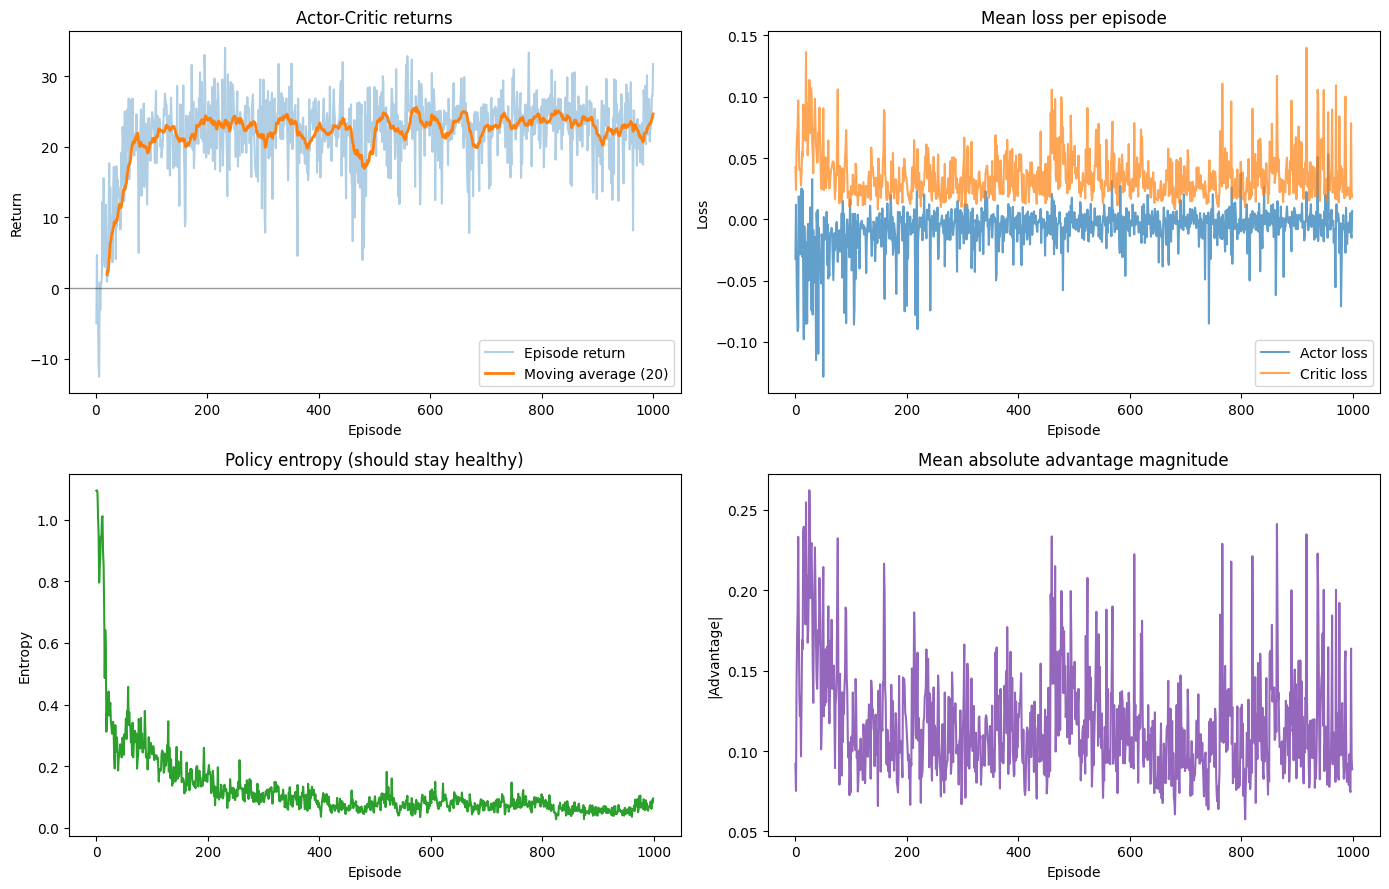

In [ ]:
# Actor-Critic with separate actor and critic networks
class Actor(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)

class Critic(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

def run_actor_critic(
    n_episodes=1000,
    max_steps=200,
    gamma=0.99,
    actor_lr=5e-4,  # Lower learning rate for stability
    critic_lr=5e-4,
    entropy_coef=0.01,  # Stronger entropy regularization
    seed=0,
    env_id='cookiedisaster/GridWorld-v0',
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(env_id)
    n_actions = env.action_space.n
    input_dim = obs_to_vec(env.reset(seed=seed)[0]).shape[0]

    actor = Actor(input_dim, n_actions)
    critic = Critic(input_dim)
    actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)
    critic_loss_fn = nn.SmoothL1Loss()

    episode_returns = []
    actor_losses = []
    critic_losses = []
    entropies = []
    advantage_stats = []

    for episode_idx in range(n_episodes):
        obs, _ = env.reset(seed=seed + episode_idx)
        state_vec = obs_to_vec(obs)
        episode_return = 0.0

        ep_actor_losses = []
        ep_critic_losses = []
        ep_entropies = []
        ep_advantages = []

        for _ in range(max_steps):
            state_tensor = torch.tensor(state_vec, dtype=torch.float32).unsqueeze(0)
            logits = actor(state_tensor)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            entropy = dist.entropy().mean()
            value = critic(state_tensor).squeeze()

            next_obs, reward, terminated, truncated, _ = env.step(int(action.item()))
            done = terminated or truncated
            next_state_vec = obs_to_vec(next_obs)
            next_state_tensor = torch.tensor(next_state_vec, dtype=torch.float32).unsqueeze(0)

            with torch.no_grad():
                next_value = torch.tensor(0.0, dtype=torch.float32) if terminated else critic(next_state_tensor).squeeze()
                td_target = torch.tensor(float(reward), dtype=torch.float32) + gamma * next_value

            advantage = td_target - value
            ep_advantages.append(float(advantage.detach().item()))

            # Actor loss: policy gradient with entropy regularization
            actor_loss = -(log_prob * advantage.detach()) - entropy_coef * entropy

            # Critic loss: Huber loss on the TD target
            critic_loss = critic_loss_fn(value, td_target.detach())

            actor_optimizer.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(actor.parameters(), 10.0)
            actor_optimizer.step()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            nn.utils.clip_grad_norm_(critic.parameters(), 10.0)
            critic_optimizer.step()

            ep_actor_losses.append(float(actor_loss.item()))
            ep_critic_losses.append(float(critic_loss.item()))
            ep_entropies.append(float(entropy.item()))
            episode_return += reward
            state_vec = next_state_vec

            if done:
                break

        episode_returns.append(float(episode_return))
        actor_losses.append(float(np.mean(ep_actor_losses)) if ep_actor_losses else 0.0)
        critic_losses.append(float(np.mean(ep_critic_losses)) if ep_critic_losses else 0.0)
        entropies.append(float(np.mean(ep_entropies)) if ep_entropies else 0.0)
        advantage_stats.append(float(np.mean(np.abs(ep_advantages))) if ep_advantages else 0.0)

    env.close()

    stats = {
        'mean_last_20': float(np.mean(episode_returns[-20:])),
        'best_return': float(np.max(episode_returns)),
        'last_10': [round(x, 3) for x in episode_returns[-10:]],
    }
    diagnostics = {
        'actor_losses': np.asarray(actor_losses, dtype=np.float32),
        'critic_losses': np.asarray(critic_losses, dtype=np.float32),
        'entropies': np.asarray(entropies, dtype=np.float32),
        'advantage_stats': np.asarray(advantage_stats, dtype=np.float32),
    }
    return episode_returns, diagnostics, actor, critic, stats

def plot_actor_critic_results(episode_returns, diagnostics, window=20):
    returns_np = np.asarray(episode_returns, dtype=float)
    episodes = np.arange(1, len(returns_np) + 1)
    window = min(window, len(returns_np)) if len(returns_np) > 0 else 1

    if len(returns_np) >= 2:
        kernel = np.ones(window, dtype=float) / window
        returns_ma = np.convolve(returns_np, kernel, mode='valid')
        returns_ma_x = np.arange(window, len(returns_np) + 1)
    else:
        returns_ma = returns_np
        returns_ma_x = episodes

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(episodes, returns_np, alpha=0.35, label='Episode return')
    axes[0, 0].plot(returns_ma_x, returns_ma, linewidth=2.0, label=f'Moving average ({window})')
    axes[0, 0].axhline(0.0, color='black', linewidth=1, alpha=0.4)
    axes[0, 0].set_title('Actor-Critic returns')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Return')
    axes[0, 0].legend()

    axes[0, 1].plot(diagnostics['actor_losses'], label='Actor loss', alpha=0.7)
    axes[0, 1].plot(diagnostics['critic_losses'], label='Critic loss', alpha=0.7)
    axes[0, 1].set_title('Mean loss per episode')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()

    axes[1, 0].plot(diagnostics['entropies'], color='tab:green')
    axes[1, 0].set_title('Policy entropy (should stay healthy)')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Entropy')

    axes[1, 1].plot(diagnostics['advantage_stats'], color='tab:purple')
    axes[1, 1].set_title('Mean absolute advantage magnitude')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('|Advantage|')

    plt.tight_layout()
    plt.show()

ac_returns, ac_diagnostics, actor_model, critic_model, ac_stats = run_actor_critic()
print('Actor-Critic training complete.')
print('Mean return last 20 episodes:', ac_stats['mean_last_20'])
print('Best return seen:', ac_stats['best_return'])
print('Last 10 returns:', ac_stats['last_10'])

plot_actor_critic_results(ac_returns, ac_diagnostics, window=20)


### (6) comparison of actor critic and the 2 previous implementations

For the actor-critic implementation above, we defined two neural networks: one actor network and one critic network. The actor network approximates the policy by outputting action logits, which is unnormalized scores for each possible discrete action. The critic network is used to approximate the state-value function. The implication here is that we get a moving target, which differs to previous implementations. 

The actor-critic solution also differs from the two previous ones because while the previous ones are so-called value-based methods, the actor-critic method learns both a policy(actor) and estimates the state-value fuction(critic). And the way it improves the policy function is by using an advantage signal to update our confidence for the selected action(advantage tells us if the action we selected was better or worse than initially believed). So, to sum it up, instead of learning an action value and state value function by approximation and greedy exploration, we let the critic estimate a value function, whilst the actor is responsible for approximating and updating policies. 

Lastly, the results we get from the actor-critic implementation reaches a higher return/episode, measured with the moving average of the last 20 runs. My takeaway here is that both the MLP-NN implementation and the actor-critic performes better than linear approximation + q-learning, and that Actor-Critic gets slightly higher returns but might have some additional variance compared to the simple NN implementation. Also added entropy as an eval metric for actor-critic because you can intepret it as uncertainty for our action "scoring". Thus, we can reason that our agent gets more confident in its learned policy with time, as entropy decreases. 

Lastly, woth noting that i am compareing with a simpler implementation of nn for function approximation, as the implementation above is without a replay buffer or target network. 

# NN with replay buffer and target network

DQN training complete.
Mean return last 20 episodes: 21.416527022626276
Best return seen: 35.52059738805929
Last 10 returns: [24.999, 24.722, 20.781, 21.254, 22.556, 14.936, 20.546, 24.951, 17.744, 19.926]


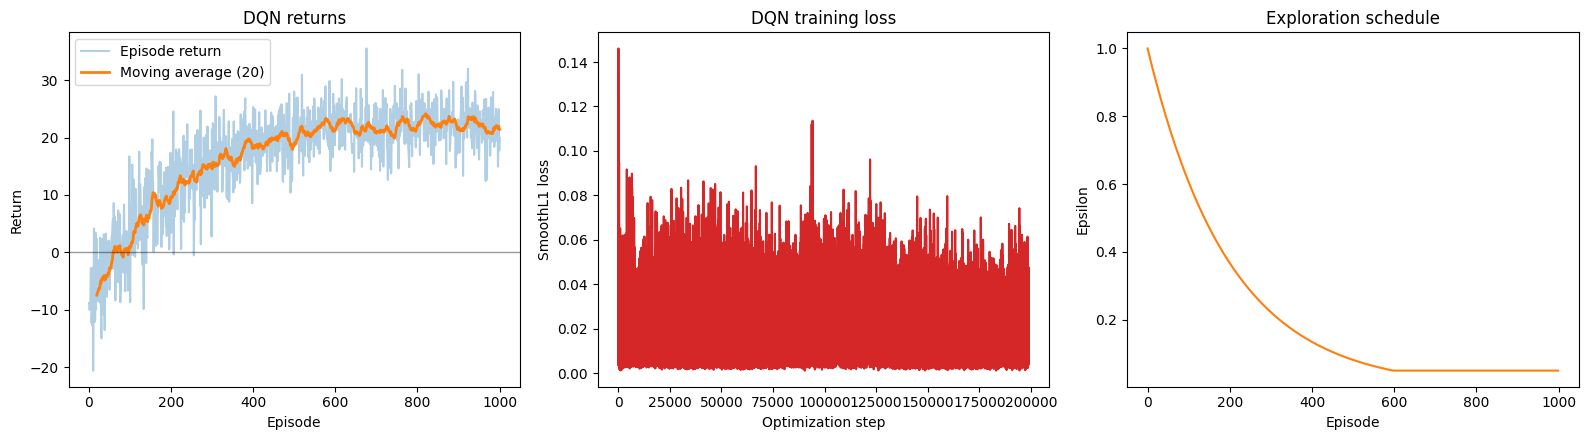

In [29]:
# Neural network with replay buffer and target network
from collections import deque
import random


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.asarray(states), dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(np.asarray(next_states), dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)


def run_dqn(
    n_episodes=1000,
    max_steps=200,
    gamma=0.99,
    learning_rate=1e-3,
    batch_size=64,
    replay_capacity=20000,
    min_buffer_size=1000,
    target_update_every=250,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    seed=0,
    env_id="cookiedisaster/GridWorld-v0",
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(env_id)
    n_actions = env.action_space.n
    input_dim = obs_to_vec(env.reset(seed=seed)[0]).shape[0]

    policy_net = DQN(input_dim, n_actions)
    target_net = DQN(input_dim, n_actions)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
    loss_fn = nn.SmoothL1Loss()
    replay_buffer = ReplayBuffer(replay_capacity)

    episode_returns = []
    losses = []
    epsilons = []
    target_sync_steps = []

    epsilon = eps_start
    global_step = 0

    for episode_idx in range(n_episodes):
        obs, _ = env.reset(seed=seed + episode_idx)
        state_vec = obs_to_vec(obs)
        episode_return = 0.0

        for _ in range(max_steps):
            global_step += 1

            if np.random.rand() < epsilon:
                action = int(np.random.randint(n_actions))
            else:
                with torch.no_grad():
                    state_tensor = torch.tensor(state_vec, dtype=torch.float32).unsqueeze(0)
                    action = int(torch.argmax(policy_net(state_tensor), dim=1).item())

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state_vec = obs_to_vec(next_obs)

            replay_buffer.push(
                state_vec,
                action,
                float(reward),
                next_state_vec,
                done,
            )

            episode_return += reward
            state_vec = next_state_vec

            if len(replay_buffer) >= min_buffer_size:
                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                q_values = policy_net(states)
                q_sa = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    next_q_values = target_net(next_states)
                    next_q_max = next_q_values.max(dim=1).values
                    td_target = rewards + gamma * (1.0 - dones) * next_q_max

                loss = loss_fn(q_sa, td_target)

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
                optimizer.step()

                losses.append(float(loss.item()))

                if global_step % target_update_every == 0:
                    target_net.load_state_dict(policy_net.state_dict())
                    target_sync_steps.append(global_step)

            if done:
                break

        episode_returns.append(float(episode_return))
        epsilons.append(float(epsilon))
        epsilon = max(eps_end, epsilon * eps_decay)

    env.close()

    stats = {
        "mean_last_20": float(np.mean(episode_returns[-20:])),
        "best_return": float(np.max(episode_returns)),
        "last_10": [round(x, 3) for x in episode_returns[-10:]],
    }

    diagnostics = {
        "losses": np.asarray(losses, dtype=np.float32),
        "epsilons": np.asarray(epsilons, dtype=np.float32),
        "target_sync_steps": np.asarray(target_sync_steps, dtype=np.int32),
    }

    return episode_returns, diagnostics, policy_net, target_net, stats


def plot_dqn_results(episode_returns, diagnostics, window=20):
    returns_np = np.asarray(episode_returns, dtype=float)
    episodes = np.arange(1, len(returns_np) + 1)

    window = min(window, len(returns_np)) if len(returns_np) > 0 else 1
    if len(returns_np) >= 2:
        kernel = np.ones(window, dtype=float) / window
        returns_ma = np.convolve(returns_np, kernel, mode="valid")
        returns_ma_x = np.arange(window, len(returns_np) + 1)
    else:
        returns_ma = returns_np
        returns_ma_x = episodes

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].plot(episodes, returns_np, alpha=0.35, label="Episode return")
    axes[0].plot(returns_ma_x, returns_ma, linewidth=2.0, label=f"Moving average ({window})")
    axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.4)
    axes[0].set_title("DQN returns")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Return")
    axes[0].legend()

    axes[1].plot(diagnostics["losses"], color="tab:red")
    axes[1].set_title("DQN training loss")
    axes[1].set_xlabel("Optimization step")
    axes[1].set_ylabel("SmoothL1 loss")

    axes[2].plot(diagnostics["epsilons"], color="tab:orange")
    axes[2].set_title("Exploration schedule")
    axes[2].set_xlabel("Episode")
    axes[2].set_ylabel("Epsilon")

    plt.tight_layout()
    plt.show()


dqn_returns, dqn_diagnostics, dqn_policy_net, dqn_target_net, dqn_stats = run_dqn()

print("DQN training complete.")
print("Mean return last 20 episodes:", dqn_stats["mean_last_20"])
print("Best return seen:", dqn_stats["best_return"])
print("Last 10 returns:", dqn_stats["last_10"])

plot_dqn_results(dqn_returns, dqn_diagnostics, window=20)